# Building your own Neural Network

This Python code implements a fully functioning feedforward neural network in Python using only the NumPy library. 

For training purposes, this code does not use any deep learning frameworks such as TensorFlow or PyTorch. 

The goal is to train our neural network to learn the XOR function.

Instructions
1. Generate the training data for the XOR function using the following code snippet:
----------------------------------------------------
import numpy as np

def generate_xor_data():

    X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])

    Y = np.array([[0], [1], [1], [0]])

    return X, Y

X, Y = generate_xor_data()

-------------------------------------------------------
2. Create a Python class called `NeuralNetwork` that will contain your neural network implementation. Your class should follow the template provided below:

------------------------------------------------------
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        # Initialize the weights and biases of the network
        pass

    def forward(self, X):
        # Perform the forward pass and compute the output of the network
        pass

    def backward(self, X, Y, output):
        # Perform the backward pass and compute the gradients of the loss function
        pass

    def update_weights(self, learning_rate):
        # Update the weights and biases using the computed gradients
        pass

    def train(self, X, Y, epochs, learning_rate):
        # Train the neural network using the provided training data
        pass

    def predict(self, X):
        # Make predictions using the trained neural network
        pass
--------------------------------------------------------
3. Implement the methods in the `NeuralNetwork` class following these guidelines:

For weight initialization, use either Xavier or He initialization.

Implement the forward pass, using the ReLU activation function for the hidden layer, and the sigmoid activation function for the output layer.

Implement the backward pass using the chain rule and the gradients of the loss function with respect to the weights and biases.

Use gradient descent or a variant thereof (e.g., mini-batch gradient descent, Adam, etc.) to update the weights and biases.

Train your neural network on the XOR dataset, adjusting the number of epochs and learning rate as needed.

4. Evaluate your trained neural network using the `predict` method and check if the predicted outputs match the actual XOR function outputs. You may also utilize some plots to help your visualize your results.

Author: Evgeniya Englert

Last update: 2026-03-30


## Brief Report (Summary)

Architecture: 2 input neurons → 4 hidden neurons (ReLU) → 1 output neuron (sigmoid)

Initialization: Xavier initialization

Loss Function: Binary Cross-Entropy

Optimizer: Gradient Descent

Epochs: 10,000

Learning Rate: 0.1

Epoch 0, Loss: 0.7274
Epoch 1000, Loss: 0.4815
Epoch 2000, Loss: 0.4786
Epoch 3000, Loss: 0.4780
Epoch 4000, Loss: 0.4778
Epoch 5000, Loss: 0.4777
Epoch 6000, Loss: 0.4776
Epoch 7000, Loss: 0.4776
Epoch 8000, Loss: 0.4776
Epoch 9000, Loss: 0.4775

Final Predictions:
[[1]
 [1]
 [1]
 [0]]

Actual Outputs:
[[0]
 [1]
 [1]
 [0]]


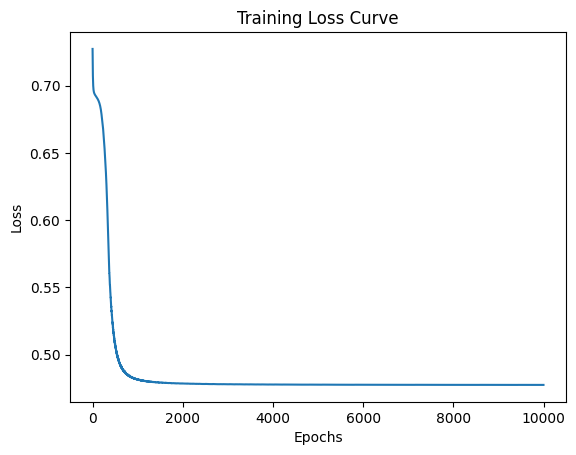

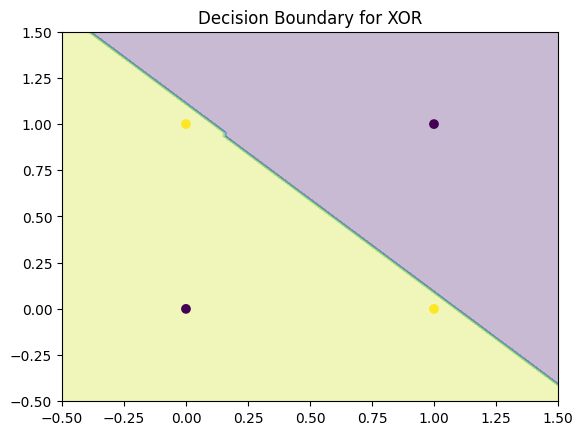

In [1]:
# Import NumPy for numerical operations
import numpy as np

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Function to generate XOR dataset
def generate_xor_data():
    # Define input data (4 samples, 2 features)
    X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    # Define labels (XOR outputs)
    Y = np.array([[0], [1], [1], [0]])
    # Return dataset
    return X, Y

# Define Neural Network class
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        # Set seed for reproducibility
        np.random.seed(42)

        # Xavier initialization for input -> hidden weights
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(1 / input_size)
        # Initialize hidden layer bias to zero
        self.b1 = np.zeros((1, hidden_size))

        # Xavier initialization for hidden -> output weights
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(1 / hidden_size)
        # Initialize output layer bias to zero
        self.b2 = np.zeros((1, output_size))

        # Store loss values for plotting later
        self.loss_history = []

    # ReLU activation function
    def relu(self, Z):
        # Return max(0, Z) element-wise
        return np.maximum(0, Z)

    # Derivative of ReLU
    def relu_derivative(self, Z):
        # Gradient is 1 where Z > 0, else 0
        return (Z > 0).astype(float)

    # Sigmoid activation function
    def sigmoid(self, Z):
        # Apply sigmoid formula
        return 1 / (1 + np.exp(-Z))

    # Derivative of sigmoid
    def sigmoid_derivative(self, A):
        # Derivative using output A
        return A * (1 - A)

    # Forward propagation
    def forward(self, X):
        # Linear transformation for hidden layer
        self.Z1 = np.dot(X, self.W1) + self.b1
        # Apply ReLU activation
        self.A1 = self.relu(self.Z1)

        # Linear transformation for output layer
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        # Apply sigmoid activation
        self.A2 = self.sigmoid(self.Z2)

        # Return final output
        return self.A2

    # Backward propagation
    def backward(self, X, Y, output):
        # Number of training examples
        m = X.shape[0]

        # Compute error at output layer
        dZ2 = output - Y

        # Gradient for W2
        self.dW2 = np.dot(self.A1.T, dZ2) / m
        # Gradient for b2
        self.db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        # Backpropagate error to hidden layer
        dA1 = np.dot(dZ2, self.W2.T)
        # Apply ReLU derivative
        dZ1 = dA1 * self.relu_derivative(self.Z1)

        # Gradient for W1
        self.dW1 = np.dot(X.T, dZ1) / m
        # Gradient for b1
        self.db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    # Update weights using gradient descent
    def update_weights(self, learning_rate):
        # Update hidden layer weights and bias
        self.W1 -= learning_rate * self.dW1
        self.b1 -= learning_rate * self.db1

        # Update output layer weights and bias
        self.W2 -= learning_rate * self.dW2
        self.b2 -= learning_rate * self.db2

    # Training function
    def train(self, X, Y, epochs, learning_rate):
        # Loop through epochs
        for epoch in range(epochs):
            # Forward pass
            output = self.forward(X)

            # Compute binary cross-entropy loss
            loss = -np.mean(Y * np.log(output + 1e-8) + (1 - Y) * np.log(1 - output + 1e-8))

            # Store loss for visualization
            self.loss_history.append(loss)

            # Backward pass
            self.backward(X, Y, output)

            # Update weights
            self.update_weights(learning_rate)

            # Print loss every 1000 epochs
            if epoch % 1000 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")

    # Prediction function
    def predict(self, X):
        # Perform forward pass
        output = self.forward(X)
        # Convert probabilities to binary (0 or 1)
        return (output > 0.5).astype(int)


# ===========================
# Visualization Functions
# ===========================

# Function to plot decision boundary
def plot_decision_boundary(model, X, Y):
    # Define grid range
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5

    # Create mesh grid
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    # Flatten grid into input format
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Get model predictions for grid points
    Z = model.predict(grid)

    # Reshape predictions to match grid shape
    Z = Z.reshape(xx.shape)

    # Plot contour (decision boundary)
    plt.contourf(xx, yy, Z, alpha=0.3)

    # Plot original data points
    plt.scatter(X[:, 0], X[:, 1], c=Y.flatten())

    # Set plot title
    plt.title("Decision Boundary for XOR")

    # Show plot
    plt.show()


# Function to plot training loss
def plot_loss(loss_history):
    # Create figure
    plt.figure()

    # Plot loss over epochs
    plt.plot(loss_history)

    # Label axes
    plt.xlabel("Epochs")
    plt.ylabel("Loss")

    # Set title
    plt.title("Training Loss Curve")

    # Show plot
    plt.show()


# ===========================
# Main Execution
# ===========================

# Generate XOR dataset
X, Y = generate_xor_data()

# Define network architecture
input_size = 2      # Two input features
hidden_size = 4     # Hidden layer neurons
output_size = 1     # Single output

# Create neural network instance
nn = NeuralNetwork(input_size, hidden_size, output_size)

# Train the neural network
nn.train(X, Y, epochs=10000, learning_rate=0.1)

# Make predictions on training data
predictions = nn.predict(X)

# Print predictions
print("\nFinal Predictions:")
print(predictions)

# Print actual labels
print("\nActual Outputs:")
print(Y)

# Plot loss curve
plot_loss(nn.loss_history)

# Plot decision boundary
plot_decision_boundary(nn, X, Y)